---
title: "Project 3: Global Mental Health Crisis Index 2026"
---

92 countries · 29 indicators· Mental health prevalence, systems & crisis scoring

## Scenario

The Global Mental Health Crisis Index 2026 is a cross-national dataset covering 92 countries across all six WHO regions, providing a comprehensive snapshot of the state of mental health worldwide as of 2025. It combines epidemiological, economic, policy, and digital behavior indicators into a single, analysis-ready file with no missing values.

### What's Inside

Each row represents one country and includes 29 variables spanning:

- **Prevalence** — depression rate (%), anxiety rate (%), and estimated comorbidity
- **Crisis severity** — a composite `mh_crisis_index` score (0–100) and `youth_mh_crisis_score`
- **Healthcare capacity** — psychiatrists per 100k population, mental health budget as % of  
    total health spending, per-capita mental health expenditure (USD)
- **Access & equity** — treatment gap (%), mental health policy/law existence (Yes/No)
- **Socioeconomic context** — GDP per capita, income group, population size
- **Digital environment** — average social media hours per day, internet penetration (%),  
    social media mental health risk category
- **COVID-19 impact** — estimated % increase in mental health burden post-pandemic
- **System quality** — an aggregated `mh_system_score` reflecting infrastructure and investment

### Data Sources

Data was compiled and harmonized from:

1. **WHO Mental Health Atlas 2024**
2. **Global Burden of Disease Study 2023** (IHME)
3. **Our World in Data** (accessed March 2026)
4. **OECD Health Statistics 2024**
5. **DataReportal 2025**

### Potential Use Cases

1. **Visualization & dashboards** — build regional heatmaps, scatter plots, or choropleth maps
2. **Social media & mental health** — explore the relationship between screen time and depression/anxiety rates
3. **COVID-19 aftermath** — analyze which regions saw the largest pandemic-era mental health surge
4. **Policy analysis** — examine the impact of mental health laws and budgets on treatment gaps
5. **Inequality research** — compare high-income vs. low-income country disparities in care access
6. **Clustering & segmentation** — group countries by mental health burden, system strength, or income level
7. **Regression & prediction** — model the crisis index from economic, digital, and policy variables

### Goal

- Showcase 5 of the above potential use cases.
- Bonus if you showcase 1 of the other two

### Load Dataset

[Dataset Hosted at Kaggle | by Syed Ali Taqi](https://www.kaggle.com/datasets/alitaqishah/global-mental-health-crisis-index-2026), and has been downloaded to `Global_Mental_Health_Crisis_Index_2026.csv`.

---

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Global_Mental_Health_Crisis_Index_2026.csv')
df.head()

,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,...,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,social_media_mental_health_risk,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year,data_source
0,Malawi,MWI,Africa,Low,3.3,4.5,6.5,0.02,0.8,0.1,...,87,1.59,0.2,0.078,Low (<1.5h),1.65,3.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
1,Mozambique,MOZ,Africa,Low,3.4,4.6,8.2,0.04,0.6,0.1,...,86,2.62,0.4,0.058,Low (<1.5h),1.70,3.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
2,Ethiopia,ETH,Africa,Low,3.5,4.8,10.2,0.04,1.0,0.1,...,84,10.24,0.4,0.095,Low (<1.5h),1.75,4.7,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
3,Zimbabwe,ZWE,Africa,Low,4.0,5.2,15.4,0.05,0.7,0.1,...,83,1.46,0.5,0.066,Moderate (1.5-2.5h),2.00,4.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
4,Tanzania,TZA,Africa,Low,3.6,4.9,8.6,0.04,0.8,0.1,...,82,5.57,0.4,0.075,Moderate (1.5-2.5h),1.80,4.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...


### Checking for data types and ensure there are no missing values

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 29 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country                                 92 non-null     str    
 1   iso3                                    92 non-null     str    
 2   region                                  92 non-null     str    
 3   income_group                            92 non-null     str    
 4   depression_pct                          92 non-null     float64
 5   anxiety_pct                             92 non-null     float64
 6   suicide_rate_per100k                    92 non-null     float64
 7   psychiatrists_per100k                   92 non-null     float64
 8   mh_budget_pct_health                    92 non-null     float64
 9   mh_spend_usd_per_capita                 92 non-null     float64
 10  treatment_gap_pct                       92 non-null     int64  
 11  social

all columns have 92 non null values so no missing values.

In [6]:
df.describe()

,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,treatment_gap_pct,social_media_hours_daily,internet_penetration_pct,gdp_per_capita_usd,...,covid_mh_increase_pct,youth_mh_crisis_score,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year
count,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,...,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.000000,92.0
mean,4.402174,5.632609,11.559783,7.182283,3.758696,38.951087,58.934783,2.209783,73.750000,22231.608696,...,49.630435,7.410870,58.293478,7.340870,71.822826,0.146359,2.201087,32.958696,2.923913,2025.0
std,0.754471,1.201657,9.825511,9.485814,2.960366,63.418593,27.884694,0.786711,24.262133,25685.337791,...,16.320766,1.211434,13.637004,18.300855,94.858139,0.048522,0.377235,27.460854,1.008030,0.0
min,2.900000,3.800000,3.200000,0.020000,0.600000,0.100000,17.000000,0.100000,8.000000,600.000000,...,26.000000,5.100000,36.000000,0.050000,0.200000,0.058000,1.450000,3.100000,1.000000,2025.0
25%,3.800000,4.800000,7.575000,0.500000,1.200000,0.725000,26.000000,1.600000,68.750000,3975.000000,...,34.750000,6.300000,45.750000,0.857500,5.000000,0.106000,1.900000,9.025000,2.000000,2025.0
50%,4.400000,5.200000,9.800000,3.150000,2.850000,8.000000,64.500000,2.100000,82.500000,10150.000000,...,48.000000,7.500000,58.000000,2.225000,31.500000,0.144500,2.200000,23.700000,3.000000,2025.0
75%,4.900000,6.100000,12.825000,12.450000,5.650000,49.750000,84.500000,2.800000,92.250000,33975.000000,...,62.000000,8.400000,69.000000,5.977500,124.500000,0.179000,2.450000,55.875000,4.000000,2025.0
max,6.300000,9.300000,87.500000,54.900000,11.300000,320.000000,97.000000,4.800000,99.000000,106900.000000,...,86.000000,9.500000,87.000000,121.430000,549.000000,0.244000,3.150000,100.000000,4.000000,2025.0


---

### Factors distribution and Relationships:

In [10]:
numeric_re = df.select_dtypes(include='number').corr()

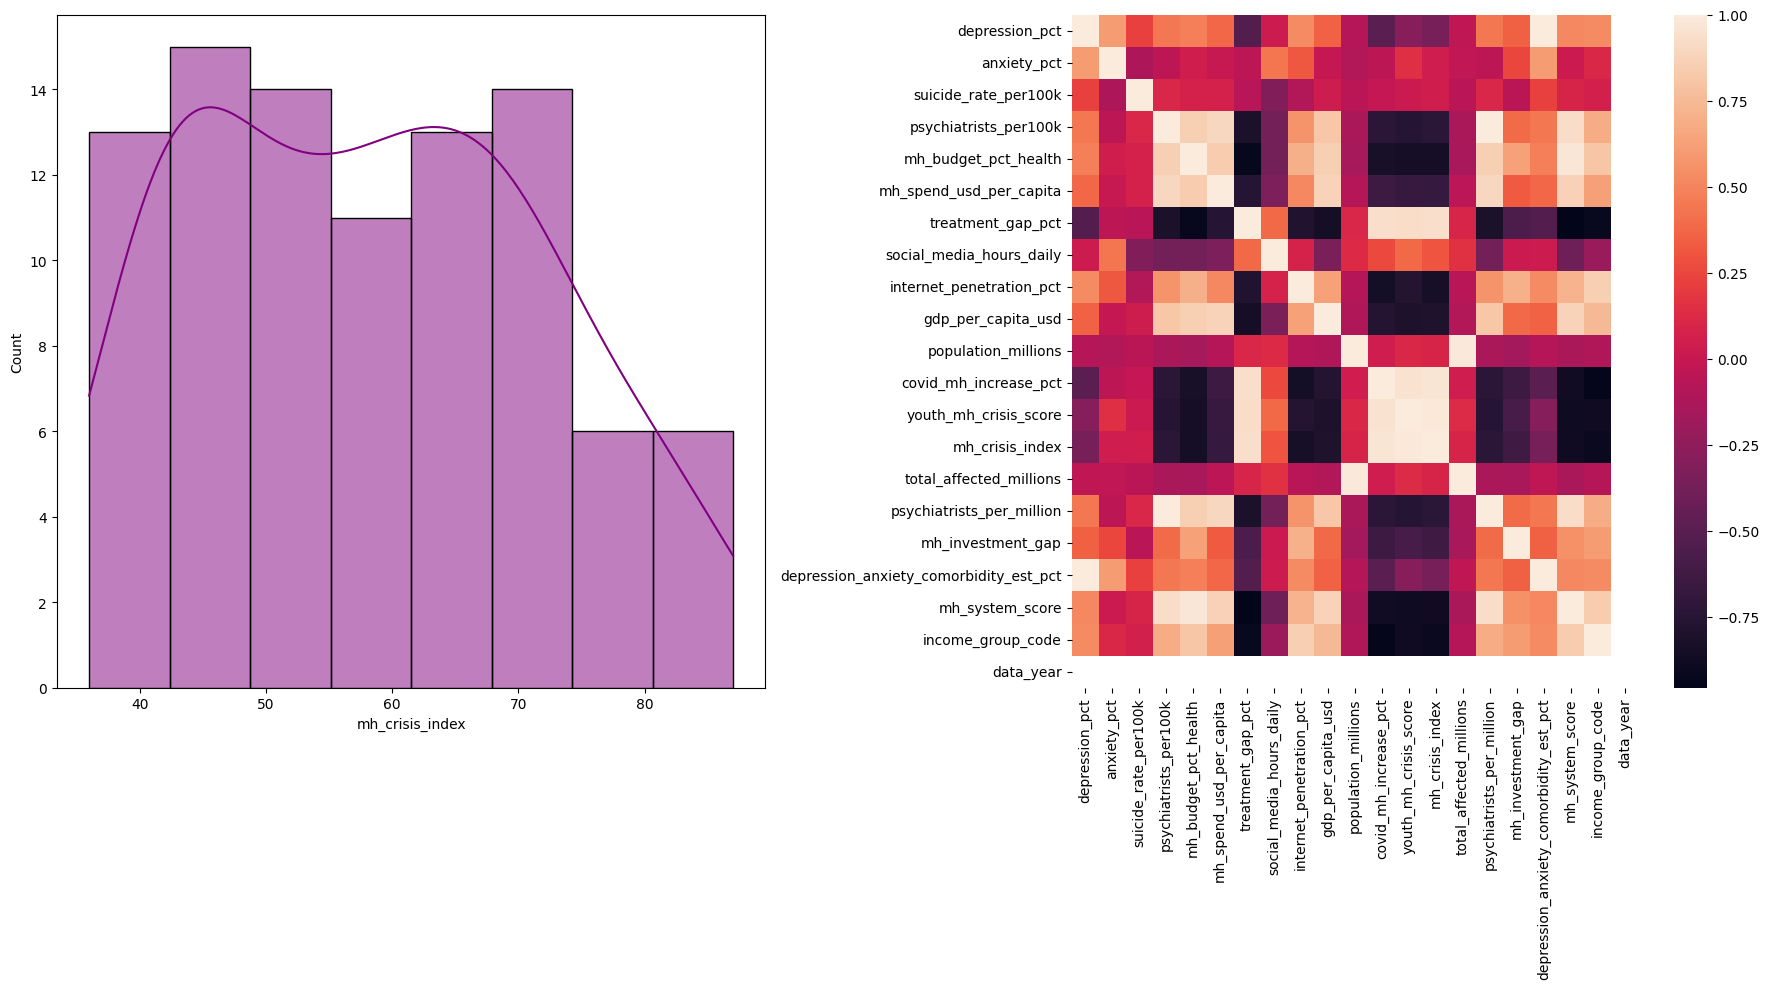

In [20]:

dig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize = (18, 10)
)

sns.histplot(
    data = df['mh_crisis_index'],
    kde= True,
    color= 'purple',
    ax = ax1
)

sns.heatmap(
    data = numeric_re,
    annot= False,
    ax = ax2
)

plt.tight_layout()

### Findings:

1. **Distribution:** most counyries have a high crisis score (70 - 100).
2. **Heatmap:** 
    1. Treatment gaps and psychiatrist have a stronger linke to the crisis than social media daily.
    2. High income helps managing the crisis.